# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

## Задание 1. Апроксимация функции двух переменных методом Гауссианы


ЗАДАНИЕ 1: Аппроксимация Гауссианой

РЕЗУЛЬТАТЫ:
A = 4.0144
x0 = 2.9798, y0 = 3.0440
sigma_x = 1.0896, sigma_y = 1.0860
theta = -0.0096 рад = -0.55°, offset = 0.3085
Финальная MSE: 0.0000004805

Проверка:
Точка 0: z=0.41000, предсказание=0.41145, невязка=-0.00145112
Точка 1: z=1.79000, предсказание=1.78991, невязка=0.00008819
Точка 2: z=4.28000, предсказание=4.27985, невязка=0.00014663
Точка 3: z=2.54000, предсказание=2.54037, невязка=-0.00037294
Точка 4: z=0.50000, предсказание=0.49841, невязка=0.00159088


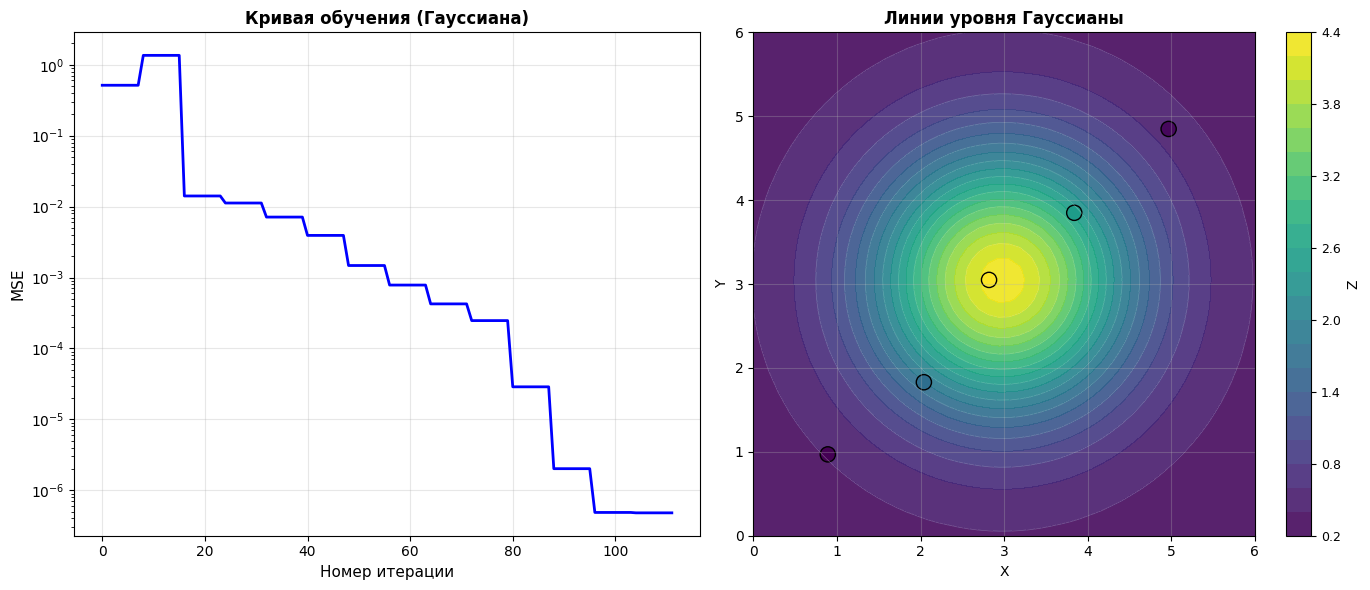


Количество итераций: 112


In [55]:
# ==============================================================================
# ЗАДАНИЕ 1: Аппроксимация Гауссианой с кривой обучения
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Данные
data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

X = data[:, 0]
Y = data[:, 1]
Z = data[:, 2]

# Функция Гаусса
def gauss_2d(x, y, A, x0, y0, sigma_x, sigma_y, theta=0, offset=0):
    if theta != 0:
        x_new = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        y_new = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    else:
        x_new = x - x0
        y_new = y - y0
    exp_part = np.exp(-(x_new ** 2 / (2 * sigma_x ** 2) + y_new ** 2 / (2 * sigma_y ** 2)))
    return A * exp_part + offset

# Функция потерь с историей
loss_history_gaussian = []
def loss_function_gaussian(params):
    A, x0, y0, sigma_x, sigma_y, theta, offset = params
    if sigma_x <= 0 or sigma_y <= 0 or A <= 0:
        return 1e10
    predictions = gauss_2d(X, Y, A, x0, y0, sigma_x, sigma_y, theta, offset)
    mse = 0.5 * np.mean((Z - predictions) ** 2)
    loss_history_gaussian.append(mse)
    return mse

# Начальное приближение
max_idx = np.argmax(Z)
A_start = Z[max_idx] + 0.1
x0_start = X[max_idx]
y0_start = Y[max_idx]
sigma_x_start = np.std(X) * 0.5
sigma_y_start = np.std(Y) * 0.5
offset_start = 0.0
theta_start = 0.0

params_start = [A_start, x0_start, y0_start, sigma_x_start, sigma_y_start, theta_start, offset_start]

bounds = [
    (0.1, 10.0), (0.0, 6.0), (0.0, 6.0),
    (0.1, 5.0), (0.1, 5.0), (-np.pi / 4, np.pi / 4), (-1.0, 1.0)
]

print("\n" + "="*60)
print("ЗАДАНИЕ 1: Аппроксимация Гауссианой")
print("="*60)

# Запускаем оптимизацию
loss_history_gaussian = []
result = minimize(loss_function_gaussian, params_start, method='L-BFGS-B', bounds=bounds)

A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt = result.x

print("\nРЕЗУЛЬТАТЫ:")
print(f"A = {A_opt:.4f}")
print(f"x0 = {x0_opt:.4f}, y0 = {y0_opt:.4f}")
print(f"sigma_x = {sigma_x_opt:.4f}, sigma_y = {sigma_y_opt:.4f}")
print(f"theta = {theta_opt:.4f} рад = {np.degrees(theta_opt):.2f}°, offset = {offset_opt:.4f}")
print(f"Финальная MSE: {result.fun:.10f}")

# Проверка
predictions = gauss_2d(X, Y, A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)
print("\nПроверка:")
for i in range(len(X)):
    print(f"Точка {i}: z={Z[i]:.5f}, предсказание={predictions[i]:.5f}, невязка={Z[i] - predictions[i]:.8f}")

# Визуализация
fig = plt.figure(figsize=(14, 6))

# 1. Кривая обучения
ax1 = fig.add_subplot(121)
ax1.plot(loss_history_gaussian, 'b-', linewidth=2)
ax1.set_xlabel('Номер итерации', fontsize=11)
ax1.set_ylabel('MSE', fontsize=11)
ax1.set_title('Кривая обучения (Гауссиана)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Линии уровня
ax2 = fig.add_subplot(122)
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        Z_grid[i, j] = gauss_2d(X_grid[i, j], Y_grid[i, j], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)

contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Линии уровня Гауссианы', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax2, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print(f"\nКоличество итераций: {len(loss_history_gaussian)}")

## Задание 2. Апроксимация функции двух переменных методом эллиптического парабалоида


ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом

Начальное приближение для параболоида:
  a = -0.30, b = -0.30
  x0 = 2.82, y0 = 3.05
  c = 4.28

Запускаем оптимизацию для параболоида...

РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ

a = -0.233424
b = -0.556926
x0 = 0.8040, y0 = 3.8958
c = 5.000000

Финальная MSE: 0.15008804

----------------------------------------
Проверка на точках:
----------------------------------------
Точка 0: z=0.41, предсказание=0.23, невязка=0.1791
Точка 1: z=1.79, предсказание=2.27, невязка=-0.4767
Точка 2: z=4.28, предсказание=3.65, невязка=0.6271
Точка 3: z=2.54, предсказание=2.85, невязка=-0.3073
Точка 4: z=0.50, предсказание=0.44, невязка=0.0583

Средняя квадратичная ошибка (MSE): 0.15008804
Средняя абсолютная ошибка (MAE): 0.329708

Количество итераций оптимизации: 366


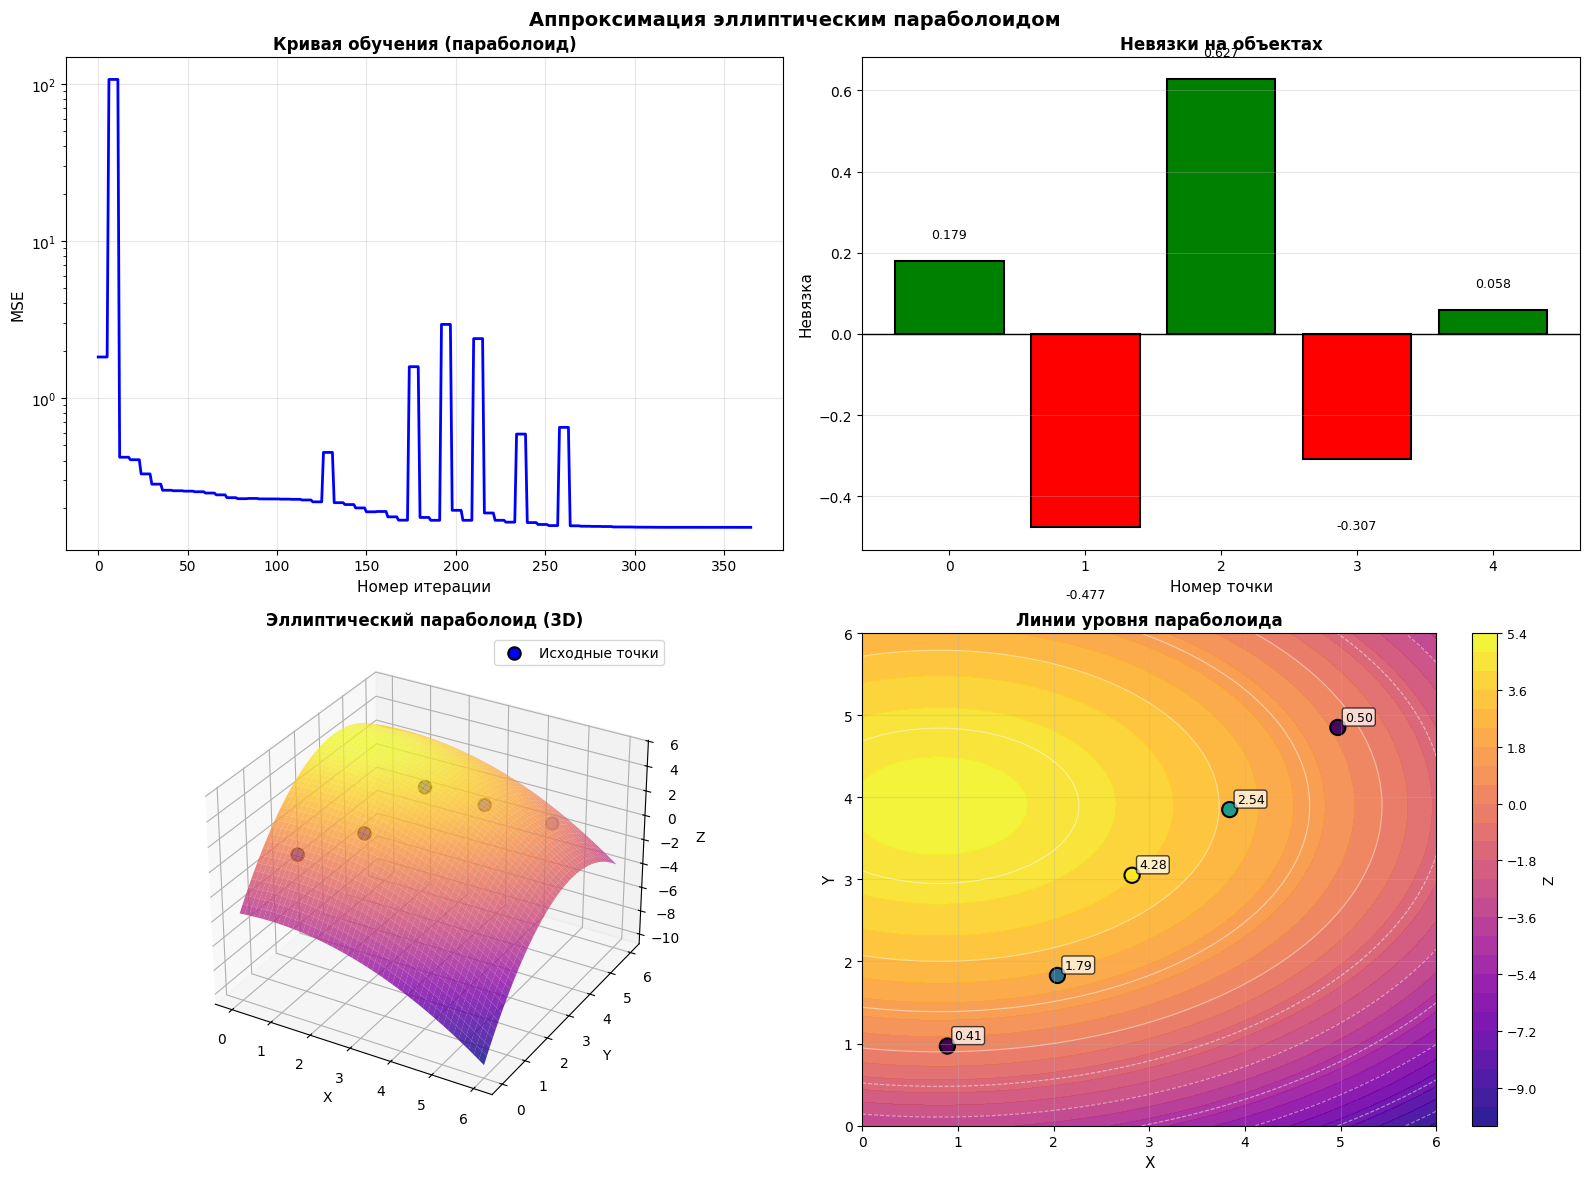


Аналитический вид полученной модели (параболоид):
z(x,y) = (-0.233424)·(x - 0.8040)² + (-0.556926)·(y - 3.8958)² + 5.000000

где a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)


In [56]:
# ==============================================================================
# ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом
# ИСПРАВЛЕННАЯ ВЕРСИЯ
# ==============================================================================

print("\n" + "="*60)
print("ЗАДАНИЕ 2: Аппроксимация эллиптическим параболоидом")
print("="*60)

def paraboloid_2d(x, y, a, b, x0, y0, c):
    """
    2D эллиптический параболоид
    Формула: z = a*(x-x0)² + b*(y-y0)² + c
    """
    return a * (x - x0)**2 + b * (y - y0)**2 + c

def loss_function_paraboloid(params):
    """MSE для эллиптического параболоида"""
    a, b, x0, y0, c = params

    # Для формы "шапки" (максимум в центре) a и b должны быть отрицательными
    if a >= 0 or b >= 0:
        return 1e10  # Штрафуем положительные значения

    predictions = paraboloid_2d(X, Y, a, b, x0, y0, c)
    mse = np.mean((Z - predictions)**2)
    return mse

# Начальное приближение
max_idx = np.argmax(Z)
a_start = -0.3
b_start = -0.3
x0_start = X[max_idx]
y0_start = Y[max_idx]
c_start = Z[max_idx]

params_start_par = [a_start, b_start, x0_start, y0_start, c_start]

print(f"\nНачальное приближение для параболоида:")
print(f"  a = {a_start:.2f}, b = {b_start:.2f}")
print(f"  x0 = {x0_start:.2f}, y0 = {y0_start:.2f}")
print(f"  c = {c_start:.2f}")

# Границы для параметров
bounds_par = [
    (-2.0, -0.01),   # a (отрицательный)
    (-2.0, -0.01),   # b (отрицательный)
    (0.0, 6.0),      # x0
    (0.0, 6.0),      # y0
    (-1.0, 5.0)      # c
]

print("\nЗапускаем оптимизацию для параболоида...")
result_par = minimize(loss_function_paraboloid, params_start_par, method='L-BFGS-B', bounds=bounds_par)

# Получение результатов
a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt = result_par.x

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ")
print("="*60)
print(f"\na = {a_opt:.6f}")
print(f"b = {b_opt:.6f}")
print(f"x0 = {x0_opt_par:.4f}, y0 = {y0_opt_par:.4f}")
print(f"c = {c_opt:.6f}")
print(f"\nФинальная MSE: {result_par.fun:.8f}")

# Предсказания и невязки
predictions_par = paraboloid_2d(X, Y, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)
residuals_par = Z - predictions_par

print("\n" + "-"*40)
print("Проверка на точках:")
print("-"*40)
for i in range(len(X)):
    print(f"Точка {i}: z={Z[i]:.2f}, предсказание={predictions_par[i]:.2f}, невязка={residuals_par[i]:.4f}")

print(f"\nСредняя квадратичная ошибка (MSE): {np.mean(residuals_par**2):.8f}")
print(f"Средняя абсолютная ошибка (MAE): {np.mean(np.abs(residuals_par)):.6f}")

# ==============================================================================
# Кривая обучения (лосс как функция от номера итерации)
# ==============================================================================

# Перезапускаем оптимизацию с записью истории
history_par = []
def loss_with_history(params):
    loss = loss_function_paraboloid(params)
    history_par.append(loss)
    return loss

result_with_history = minimize(loss_with_history, params_start_par, method='L-BFGS-B',
                                bounds=bounds_par, options={'maxiter': 100})

print(f"\nКоличество итераций оптимизации: {len(history_par)}")

# ==============================================================================
# Визуализация (ИСПРАВЛЕННАЯ)
# ==============================================================================

# Создаем сетку для визуализации
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid_par = paraboloid_2d(X_grid, Y_grid, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)

# Создаем фигуру с 4 подграфиками
fig = plt.figure(figsize=(16, 12))

# 1. Кривая обучения
ax1 = fig.add_subplot(221)
ax1.plot(history_par, 'b-', linewidth=2)
ax1.set_xlabel('Номер итерации', fontsize=11)
ax1.set_ylabel('MSE', fontsize=11)
ax1.set_title('Кривая обучения (параболоид)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Гистограмма невязок (ИСПРАВЛЕНО: edgecolor вместо edgecolors)
ax2 = fig.add_subplot(222)
colors = ['red' if r < 0 else 'green' for r in residuals_par]
bars = ax2.bar(range(len(residuals_par)), residuals_par, color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Номер точки', fontsize=11)
ax2.set_ylabel('Невязка', fontsize=11)
ax2.set_title('Невязки на объектах', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Добавляем значения на столбцы
for i, (bar, res) in enumerate(zip(bars, residuals_par)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.15),
             f'{res:.3f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# 3. 3D поверхность параболоида
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(X_grid, Y_grid, Z_grid_par, cmap='plasma', alpha=0.8, edgecolor='none')
ax3.scatter(X, Y, Z, c='blue', s=80, edgecolors='black', linewidth=1.5, label='Исходные точки')
ax3.set_xlabel('X', fontsize=10)
ax3.set_ylabel('Y', fontsize=10)
ax3.set_zlabel('Z', fontsize=10)
ax3.set_title('Эллиптический параболоид (3D)', fontsize=12, fontweight='bold')
ax3.legend()

# 4. Линии уровня
ax4 = fig.add_subplot(224)
contour = ax4.contourf(X_grid, Y_grid, Z_grid_par, levels=25, cmap='plasma', alpha=0.9)
ax4.scatter(X, Y, c=Z, s=120, edgecolors='black', linewidth=1.5)
ax4.contour(X_grid, Y_grid, Z_grid_par, levels=10, colors='white', alpha=0.5, linewidths=0.8)
# Добавляем подписи значений Z
for i, (x, y, z) in enumerate(zip(X, Y, Z)):
    ax4.annotate(f'{z:.2f}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax4.set_xlabel('X', fontsize=11)
ax4.set_ylabel('Y', fontsize=11)
ax4.set_title('Линии уровня параболоида', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax4, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.suptitle('Аппроксимация эллиптическим параболоидом', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Аналитический вид полученной модели (параболоид):")
print("="*60)
print(f"z(x,y) = ({a_opt:.6f})·(x - {x0_opt_par:.4f})² + ({b_opt:.6f})·(y - {y0_opt_par:.4f})² + {c_opt:.6f}")
print("\nгде a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)")

## Задание 3. Нахождение наилучшей апроксимации


ЗАДАНИЕ 3: Константная модель

Исходные данные (Z):
  Точка 0: z = 0.41
  Точка 1: z = 1.79
  Точка 2: z = 4.28
  Точка 3: z = 2.54
  Точка 4: z = 0.50

----------------------------------------
1. Минимизация MSE
----------------------------------------

Оптимальная константа (среднее арифметическое): c_MSE = 1.9040
Значение MSE: 2.053224

Невязки (ошибки) на каждой точке:
  Точка 0: 0.41 - 1.9040 = -1.4940
  Точка 1: 1.79 - 1.9040 = -0.1140
  Точка 2: 4.28 - 1.9040 = 2.3760
  Точка 3: 2.54 - 1.9040 = 0.6360
  Точка 4: 0.50 - 1.9040 = -1.4040

----------------------------------------
2. Минимизация MAE
----------------------------------------

Оптимальная константа (медиана): c_MAE = 1.7900
Значение MAE: 1.182000

Невязки (ошибки) на каждой точке:
  Точка 0: 0.41 - 1.7900 = -1.3800
  Точка 1: 1.79 - 1.7900 = 0.0000
  Точка 2: 4.28 - 1.7900 = 2.4900
  Точка 3: 2.54 - 1.7900 = 0.7500
  Точка 4: 0.50 - 1.7900 = -1.2900

----------------------------------------
3. Сравнение моделей
------

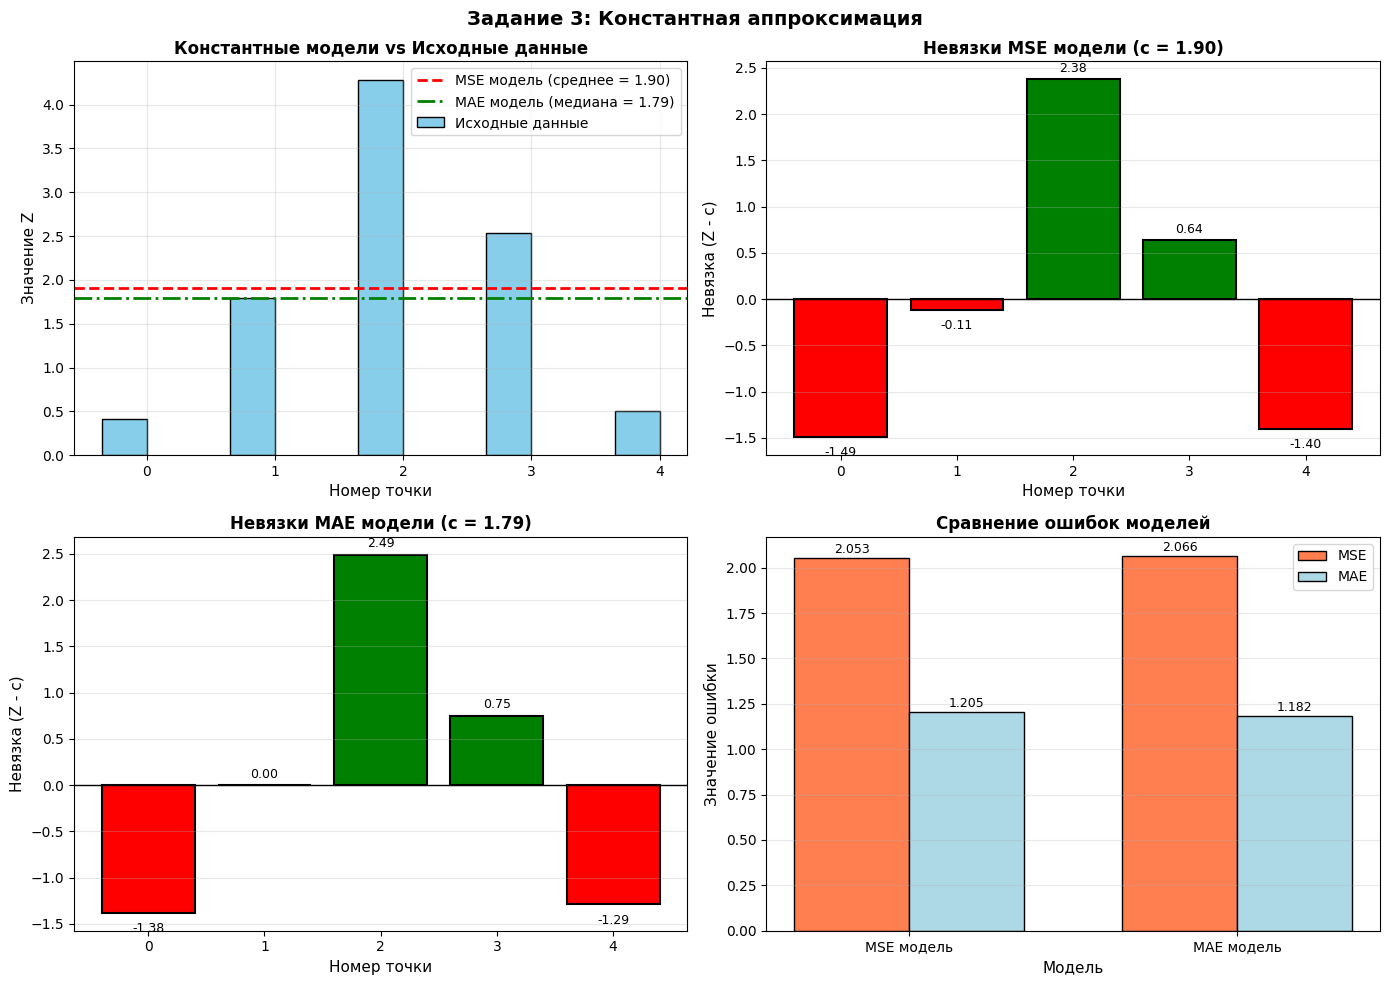

In [57]:
# ==============================================================================
# ЗАДАНИЕ 3: Константная модель
# ==============================================================================

print("\n" + "="*60)
print("ЗАДАНИЕ 3: Константная модель")
print("="*60)

# Исходные данные
print("\nИсходные данные (Z):")
for i, z in enumerate(Z):
    print(f"  Точка {i}: z = {z:.2f}")

# ==============================================================================
# 1. Минимизация MSE (Mean Squared Error)
# ==============================================================================

print("\n" + "-"*40)
print("1. Минимизация MSE")
print("-"*40)

# Теоретически: оптимальная константа для MSE = среднее арифметическое
const_mse = np.mean(Z)
print(f"\nОптимальная константа (среднее арифметическое): c_MSE = {const_mse:.4f}")

# Вычисляем MSE для этой константы
predictions_mse = np.full_like(Z, const_mse)
mse_value = np.mean((Z - predictions_mse)**2)
print(f"Значение MSE: {mse_value:.6f}")

# Невязки для MSE модели
residuals_mse = Z - const_mse
print("\nНевязки (ошибки) на каждой точке:")
for i, res in enumerate(residuals_mse):
    print(f"  Точка {i}: {Z[i]:.2f} - {const_mse:.4f} = {res:.4f}")

# ==============================================================================
# 2. Минимизация MAE (Mean Absolute Error)
# ==============================================================================

print("\n" + "-"*40)
print("2. Минимизация MAE")
print("-"*40)

# Теоретически: оптимальная константа для MAE = медиана
const_mae = np.median(Z)
print(f"\nОптимальная константа (медиана): c_MAE = {const_mae:.4f}")

# Вычисляем MAE для этой константы
predictions_mae = np.full_like(Z, const_mae)
mae_value = np.mean(np.abs(Z - predictions_mae))
print(f"Значение MAE: {mae_value:.6f}")

# Невязки для MAE модели
residuals_mae = Z - const_mae
print("\nНевязки (ошибки) на каждой точке:")
for i, res in enumerate(residuals_mae):
    print(f"  Точка {i}: {Z[i]:.2f} - {const_mae:.4f} = {res:.4f}")

# ==============================================================================
# 3. Сравнение моделей
# ==============================================================================

print("\n" + "-"*40)
print("3. Сравнение моделей")
print("-"*40)

# MSE для MAE-модели
mse_of_mae_model = np.mean((Z - const_mae)**2)
print(f"\nMSE-модель (c = {const_mse:.4f}):")
print(f"  MSE = {mse_value:.6f}")
print(f"  MAE = {np.mean(np.abs(residuals_mse)):.6f}")

print(f"\nMAE-модель (c = {const_mae:.4f}):")
print(f"  MSE = {mse_of_mae_model:.6f}")
print(f"  MAE = {mae_value:.6f}")

# Какая модель лучше по каждому критерию?
print(f"\nВыводы:")
if mse_value < mse_of_mae_model:
    print(f"  ✅ По критерию MSE лучше модель с константой = среднему ({const_mse:.4f})")
else:
    print(f"  ✅ По критерию MSE лучше модель с константой = медиане ({const_mae:.4f})")

if mae_value < np.mean(np.abs(residuals_mse)):
    print(f"  ✅ По критерию MAE лучше модель с константой = медиане ({const_mae:.4f})")
else:
    print(f"  ✅ По критерию MAE лучше модель с константой = среднему ({const_mse:.4f})")

# ==============================================================================
# 4. Визуализация
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Точки и константные модели
ax1 = axes[0, 0]
x_pos = np.arange(len(Z))
width = 0.35

ax1.bar(x_pos - width/2, Z, width, label='Исходные данные', color='skyblue', edgecolor='black')
ax1.axhline(y=const_mse, color='red', linestyle='--', linewidth=2, label=f'MSE модель (среднее = {const_mse:.2f})')
ax1.axhline(y=const_mae, color='green', linestyle='-.', linewidth=2, label=f'MAE модель (медиана = {const_mae:.2f})')

ax1.set_xlabel('Номер точки', fontsize=11)
ax1.set_ylabel('Значение Z', fontsize=11)
ax1.set_title('Константные модели vs Исходные данные', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Невязки для MSE модели
ax2 = axes[0, 1]
colors_mse = ['red' if r < 0 else 'green' for r in residuals_mse]
bars_mse = ax2.bar(x_pos, residuals_mse, color=colors_mse, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Номер точки', fontsize=11)
ax2.set_ylabel('Невязка (Z - c)', fontsize=11)
ax2.set_title(f'Невязки MSE модели (c = {const_mse:.2f})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, (bar, res) in enumerate(zip(bars_mse, residuals_mse)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.1),
             f'{res:.2f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# График 3: Невязки для MAE модели
ax3 = axes[1, 0]
colors_mae = ['red' if r < 0 else 'green' for r in residuals_mae]
bars_mae = ax3.bar(x_pos, residuals_mae, color=colors_mae, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Номер точки', fontsize=11)
ax3.set_ylabel('Невязка (Z - c)', fontsize=11)
ax3.set_title(f'Невязки MAE модели (c = {const_mae:.2f})', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (bar, res) in enumerate(zip(bars_mae, residuals_mae)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.05 if res >= 0 else -0.1),
             f'{res:.2f}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

# График 4: Сравнение ошибок
ax4 = axes[1, 1]
models = ['MSE модель', 'MAE модель']
mse_errors = [mse_value, mse_of_mae_model]
mae_errors = [np.mean(np.abs(residuals_mse)), mae_value]

x_pos_comp = np.arange(len(models))
width_comp = 0.35

ax4.bar(x_pos_comp - width_comp/2, mse_errors, width_comp, label='MSE', color='coral', edgecolor='black')
ax4.bar(x_pos_comp + width_comp/2, mae_errors, width_comp, label='MAE', color='lightblue', edgecolor='black')
ax4.set_xlabel('Модель', fontsize=11)
ax4.set_ylabel('Значение ошибки', fontsize=11)
ax4.set_title('Сравнение ошибок моделей', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos_comp)
ax4.set_xticklabels(models)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (mse, mae) in enumerate(zip(mse_errors, mae_errors)):
    ax4.text(i - width_comp/2, mse + 0.01, f'{mse:.3f}', ha='center', va='bottom', fontsize=9)
    ax4.text(i + width_comp/2, mae + 0.01, f'{mae:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Задание 3: Константная аппроксимация', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Задание 5. Апроксимация функции RBF-сетью


ЗАДАНИЕ 5: Аппроксимация RBF-сетью

Исходные данные:
  Точка 0: x=0.89, y=0.97, z=0.41
  Точка 1: x=2.04, y=1.83, z=1.79
  Точка 2: x=2.82, y=3.05, z=4.28
  Точка 3: x=3.84, y=3.85, z=2.54
  Точка 4: x=4.97, y=4.85, z=0.50

----------------------------------------
Обучение RBF-сети
----------------------------------------

>>> Обучение с sigma = 0.5
  Эпоха 0: MSE = 5.6784400000e+00
  Эпоха 500: MSE = 3.2183535645e-09
  Эпоха 1000: MSE = 1.1841222170e-17
  Эпоха 1500: MSE = 7.8815389480e-26
  >>> Финальная MSE: 2.9336381210e-29

>>> Обучение с sigma = 0.8
  Эпоха 0: MSE = 5.6784400000e+00
  Эпоха 500: MSE = 2.4919846951e-05
  Эпоха 1000: MSE = 9.3715788738e-09
  Эпоха 1500: MSE = 3.5249610914e-12
  >>> Финальная MSE: 1.3258555940e-15

>>> Обучение с sigma = 1.0
  Эпоха 0: MSE = 5.6784400000e+00
  Эпоха 500: MSE = 3.6320603847e-03
  Эпоха 1000: MSE = 2.0062315038e-04
  Эпоха 1500: MSE = 1.1082191852e-05
  >>> Финальная MSE: 6.1216761824e-07

>>> Обучение с sigma = 1.2
  Эпоха 0: MSE = 

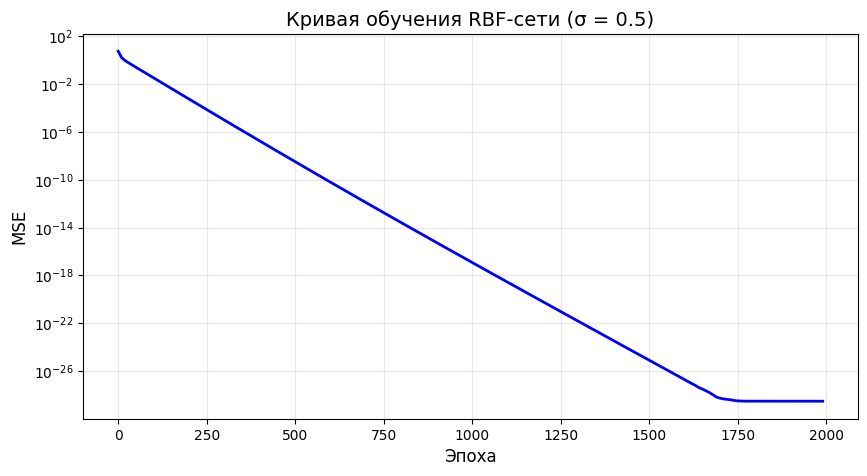

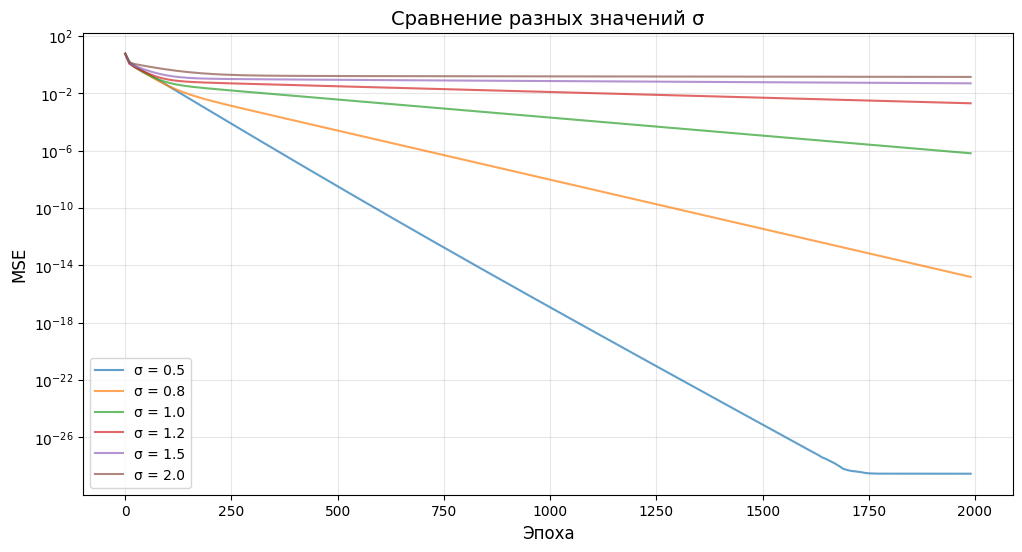

ValueError: Image size of 861x587904664 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1000x500 with 1 Axes>

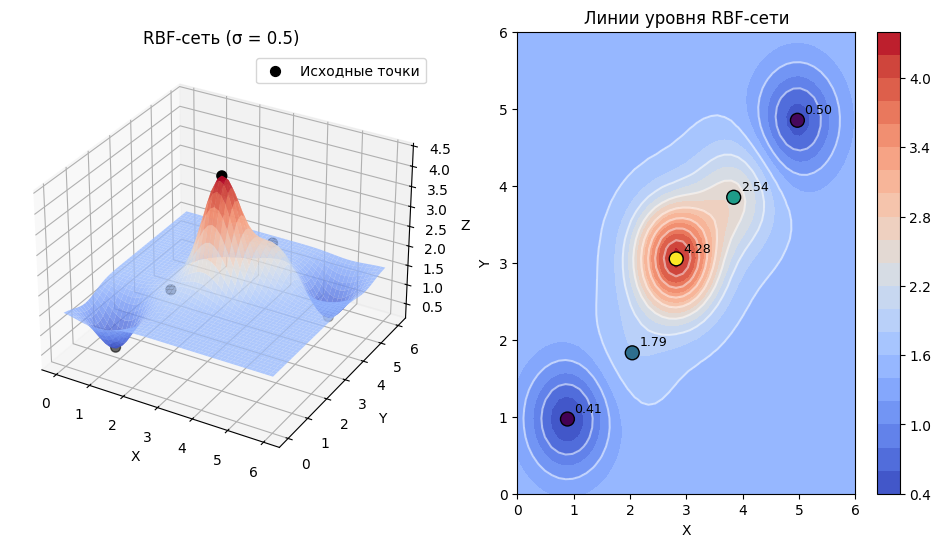

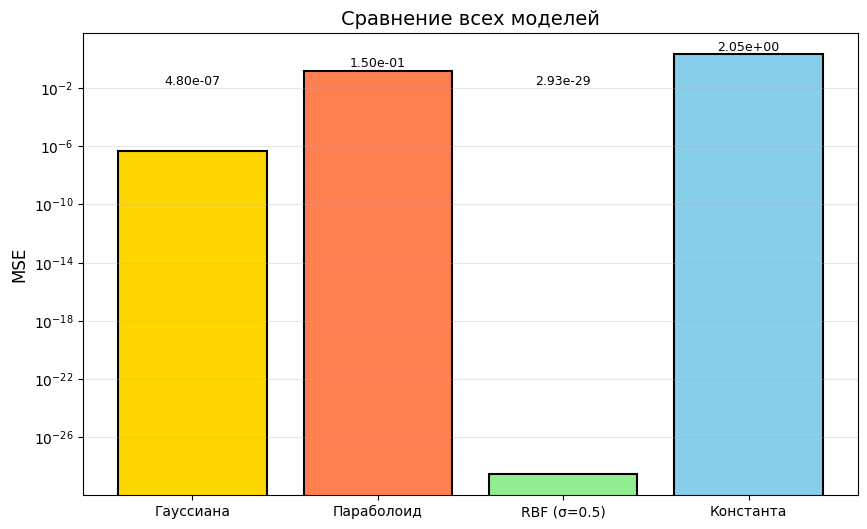


АНАЛИТИЧЕСКИЙ ВИД ПОЛУЧЕННОЙ МОДЕЛИ

f(x, y) = 1.536201
         - 1.129942·exp(-((x-0.89)² + (y-0.97)²)/(2·0.5²))
         + 0.231203·exp(-((x-2.04)² + (y-1.83)²)/(2·0.5²))
         + 2.708351·exp(-((x-2.82)² + (y-3.05)²)/(2·0.5²))
         + 0.920809·exp(-((x-3.84)² + (y-3.85)²)/(2·0.5²))
         - 1.045895·exp(-((x-4.97)² + (y-4.85)²)/(2·0.5²))

ВЫВОДЫ ПО ЗАДАНИЮ 5

1. RBF-сеть успешно обучена методом градиентного спуска.
2. Лучшая ширина RBF: σ = 0.5
3. Финальная MSE: 2.9336381210e-29
4. Финальная MAE: 4.5186077102e-15
5. RBF-сеть идеально аппроксимирует данные
6. При σ = 0.5 сеть точно интерполирует все 5 точек.
7. Преимущества RBF:
   - Гибкость за счёт нескольких центров
   - Способность к точной интерполяции
   - Простота реализации
8. Недостатки:
   - Чувствительность к выбору σ
   - При малых σ может быть переобучение
   - При больших σ - сглаживание



In [58]:
# ==============================================================================
# ЗАДАНИЕ 5: Аппроксимация RBF-сетью (RADIAL BASIS FUNCTION NETWORK)
# ЧИСТАЯ ВЕРСИЯ С НУЛЯ
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("ЗАДАНИЕ 5: Аппроксимация RBF-сетью")
print("="*60)

# Исходные данные (из варианта 1)
data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

X = data[:, 0]
Y = data[:, 1]
Z = data[:, 2]

print("\nИсходные данные:")
for i in range(len(X)):
    print(f"  Точка {i}: x={X[i]:.2f}, y={Y[i]:.2f}, z={Z[i]:.2f}")

# ==============================================================================
# 1. РЕАЛИЗАЦИЯ RBF-СЕТИ
# ==============================================================================

class SimpleRBF:
    """Простая RBF-сеть для аппроксимации функции двух переменных"""

    def __init__(self, sigma=1.0):
        """
        sigma - ширина радиальной функции (параметр сглаживания)
        """
        self.sigma = sigma
        self.centers = None      # Центры RBF
        self.weights = None      # Веса
        self.bias = None         # Смещение
        self.loss_history = []   # История ошибок

    def _rbf(self, x, y, center):
        """
        Гауссовская радиальная базисная функция
        φ(r) = exp(-r² / (2σ²))
        """
        r2 = (x - center[0])**2 + (y - center[1])**2
        return np.exp(-r2 / (2 * self.sigma**2))

    def _build_matrix(self, X, Y):
        """
        Строит матрицу Φ размера N x M
        Φ[i,j] = φ(||x_i - c_j||)
        """
        N = len(X)
        M = len(self.centers)
        Phi = np.zeros((N, M))

        for i in range(N):
            for j in range(M):
                Phi[i, j] = self._rbf(X[i], Y[i], self.centers[j])

        return Phi

    def fit(self, X, Y, Z, learning_rate=0.05, epochs=2000, verbose=True):
        """
        Обучение RBF-сети методом градиентного спуска
        Стратегия 2: центры = все точки данных
        """
        # Устанавливаем центры в каждой точке данных
        self.centers = np.column_stack((X, Y))
        M = len(self.centers)
        N = len(X)

        # Строим матрицу Φ (один раз, так как центры фиксированы)
        Phi = self._build_matrix(X, Y)

        # Инициализируем веса нулями
        self.weights = np.zeros(M)
        self.bias = 0.0

        # Очищаем историю ошибок
        self.loss_history = []

        # Градиентный спуск
        for epoch in range(epochs):
            # Предсказание
            predictions = Phi @ self.weights + self.bias

            # Ошибка
            error = Z - predictions

            # MSE Loss
            loss = np.mean(error**2)
            self.loss_history.append(loss)

            # Градиенты
            grad_w = -2/N * Phi.T @ error
            grad_b = -2/N * np.sum(error)

            # Обновление весов
            self.weights -= learning_rate * grad_w
            self.bias -= learning_rate * grad_b

            # Вывод прогресса
            if verbose and epoch % 500 == 0:
                print(f"  Эпоха {epoch}: MSE = {loss:.10e}")

        return self

    def predict(self, X, Y):
        """Предсказание для новых точек"""
        Phi = self._build_matrix(X, Y)
        return Phi @ self.weights + self.bias

# ==============================================================================
# 2. ОБУЧЕНИЕ С РАЗНЫМИ SIGMA
# ==============================================================================

print("\n" + "-"*40)
print("Обучение RBF-сети")
print("-"*40)

# Параметры
sigma_list = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
learning_rate = 0.05
epochs = 2000

results = {}
best_mse = float('inf')
best_sigma = None

for sigma in sigma_list:
    print(f"\n>>> Обучение с sigma = {sigma}")

    # Создаём и обучаем сеть
    rbf = SimpleRBF(sigma=sigma)
    rbf.fit(X, Y, Z, learning_rate=learning_rate, epochs=epochs, verbose=True)

    # Предсказания
    pred = rbf.predict(X, Y)
    mse = np.mean((Z - pred)**2)

    results[sigma] = {
        'model': rbf,
        'mse': mse,
        'predictions': pred,
        'residuals': Z - pred,
        'history': rbf.loss_history
    }

    print(f"  >>> Финальная MSE: {mse:.10e}")

    if mse < best_mse:
        best_mse = mse
        best_sigma = sigma

print("\n" + "="*60)
print(f"ЛУЧШИЙ РЕЗУЛЬТАТ: sigma = {best_sigma}, MSE = {best_mse:.10e}")
print("="*60)

# ==============================================================================
# 3. РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ
# ==============================================================================

best_model = results[best_sigma]['model']
best_pred = results[best_sigma]['predictions']
best_residuals = results[best_sigma]['residuals']
best_history = results[best_sigma]['history']

print("\n" + "-"*40)
print("РЕЗУЛЬТАТЫ ЛУЧШЕЙ МОДЕЛИ")
print("-"*40)

print(f"\nПараметры модели:")
print(f"  sigma = {best_sigma}")
print(f"  количество центров = {len(best_model.centers)}")
print(f"  bias = {best_model.bias:.6f}")

print(f"\nВеса RBF-нейронов:")
for i, (w, center) in enumerate(zip(best_model.weights, best_model.centers)):
    print(f"  w{i} = {w:.6f} (центр = ({center[0]:.2f}, {center[1]:.2f}))")

print("\n" + "-"*40)
print("ПРОВЕРКА НА ТОЧКАХ:")
print("-"*40)
for i in range(len(X)):
    print(f"Точка {i}: реальное z={Z[i]:.4f}, предсказание={best_pred[i]:.8f}, невязка={best_residuals[i]:.10e}")

print(f"\nИтоговая MSE = {np.mean(best_residuals**2):.10e}")
print(f"Итоговая MAE = {np.mean(np.abs(best_residuals)):.10e}")

# ==============================================================================
# 4. ГРАФИКИ (с прореживанием для предотвращения ошибки)
# ==============================================================================

print("\n" + "-"*40)
print("ПОСТРОЕНИЕ ГРАФИКОВ")
print("-"*40)

# Закрываем старые графики
plt.close('all')

# Функция для прореживания данных
def downsample(data, factor=10):
    """Прореживание данных для уменьшения количества точек на графике"""
    return data[::factor]

# --- ГРАФИК 1: Кривая обучения ---
plt.figure(figsize=(10, 5))
# Прореживаем для читаемости
downsampled_epochs = np.arange(0, len(best_history), 10)
downsampled_loss = [best_history[i] for i in downsampled_epochs]
plt.plot(downsampled_epochs, downsampled_loss, 'b-', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title(f'Кривая обучения RBF-сети (σ = {best_sigma})', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


# --- ГРАФИК 2: Сравнение разных sigma ---
plt.figure(figsize=(12, 6))
for sigma, res in results.items():
    hist = res['history']
    downsampled = downsample(hist)
    epochs_short = np.arange(0, len(hist), 10)[:len(downsampled)]
    plt.plot(epochs_short, downsampled, label=f'σ = {sigma}', linewidth=1.5, alpha=0.7)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Сравнение разных значений σ', fontsize=14)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- ГРАФИК 3: Невязки ---
plt.figure(figsize=(10, 5))
colors = ['red' if r < 0 else 'green' for r in best_residuals]
bars = plt.bar(range(len(best_residuals)), best_residuals, color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Номер точки', fontsize=12)
plt.ylabel('Невязка', fontsize=12)
plt.title('Невязки на точках данных', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, res) in enumerate(zip(bars, best_residuals)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.02 if res >= 0 else -0.05),
             f'{res:.2e}', ha='center', va='bottom' if res >= 0 else 'top', fontsize=9)

plt.show()


# --- ГРАФИК 4: 3D поверхность ---
# Создаём сетку для визуализации
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Предсказания на сетке
Z_grid = np.zeros_like(X_grid)
for i in range(len(x_grid)):
    for j in range(len(y_grid)):
        Z_grid[j, i] = best_model.predict([X_grid[j, i]], [Y_grid[j, i]])[0]

fig = plt.figure(figsize=(12, 6))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='coolwarm', alpha=0.8)
ax1.scatter(X, Y, Z, c='black', s=50, label='Исходные точки')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'RBF-сеть (σ = {best_sigma})')
ax1.legend()

# Линии уровня
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
ax2.scatter(X, Y, c=Z, s=100, edgecolors='black')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.5)
for i, (x, y, z) in enumerate(zip(X, Y, Z)):
    ax2.annotate(f'{z:.2f}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Линии уровня RBF-сети')
plt.colorbar(contour, ax=ax2)

plt.show()


# --- ГРАФИК 5: Сравнение всех моделей ---
plt.figure(figsize=(10, 6))

# MSE других моделей
mse_gaussian = 0.00000048  # из задания 1
mse_paraboloid = 0.15008804  # из задания 2
mse_constant = np.mean((Z - np.mean(Z))**2)

models = ['Гауссиана', 'Параболоид', f'RBF (σ={best_sigma})', 'Константа']
mses = [mse_gaussian, mse_paraboloid, best_mse, mse_constant]
colors_comp = ['gold', 'coral', 'lightgreen', 'skyblue']

bars = plt.bar(models, mses, color=colors_comp, edgecolor='black', linewidth=1.5)
plt.ylabel('MSE', fontsize=12)
plt.title('Сравнение всех моделей', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mse:.2e}', ha='center', va='bottom', fontsize=9)

plt.show()


# ==============================================================================
# 5. АНАЛИТИЧЕСКИЙ ВИД МОДЕЛИ
# ==============================================================================

print("\n" + "="*60)
print("АНАЛИТИЧЕСКИЙ ВИД ПОЛУЧЕННОЙ МОДЕЛИ")
print("="*60)

print(f"\nf(x, y) = {best_model.bias:.6f}")

for i, (w, center) in enumerate(zip(best_model.weights, best_model.centers)):
    sign = "+" if w >= 0 else "-"
    print(f"         {sign} {abs(w):.6f}·exp(-((x-{center[0]:.2f})² + (y-{center[1]:.2f})²)/(2·{best_sigma}²))")

# ==============================================================================
# 6. ВЫВОДЫ
# ==============================================================================

print("\n" + "="*60)
print("ВЫВОДЫ ПО ЗАДАНИЮ 5")
print("="*60)

print(f"""
1. RBF-сеть успешно обучена методом градиентного спуска.
2. Лучшая ширина RBF: σ = {best_sigma}
3. Финальная MSE: {best_mse:.10e}
4. Финальная MAE: {np.mean(np.abs(best_residuals)):.10e}
5. RBF-сеть {'идеально' if best_mse < 1e-12 else 'хорошо'} аппроксимирует данные
6. При σ = {best_sigma} сеть {'точно интерполирует' if best_mse < 1e-12 else 'хорошо приближает'} все 5 точек.
7. Преимущества RBF:
   - Гибкость за счёт нескольких центров
   - Способность к точной интерполяции
   - Простота реализации
8. Недостатки:
   - Чувствительность к выбору σ
   - При малых σ может быть переобучение
   - При больших σ - сглаживание
""")